In [7]:
import pandas as pd
import requests

API_KEY = "b2f10217e4419203b51cddefcc979791"

api_url = "https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?MAP_KEY=b2f10217e4419203b51cddefcc979791"

response = requests.get(api_url)

if response.status_code == 200:
    data = response.json()
    df = pd.Series(data)
    display(df)
else:
    print("Request failed.")
    print("Reason:", response.text)

#time.sleep(1)

transaction_limit             5000
current_transactions             0
transaction_interval    10 minutes
dtype: object

In [8]:
def get_transaction_count() :
  count = 0
  try:
    response = requests.get(api_url)
    data = response.json()
    df = pd.Series(data)
    count = df['current_transactions']
  except:
    print ("Error in our call.")
  return count

tcount = get_transaction_count()
print ('Our current transaction count is %i' % tcount)

Our current transaction count is 0


In [9]:
# this url will return information about all supported sensors and their corresponding datasets
# instead of 'all' you can specify individual sensor, ex:LANDSAT_NRT
da_url = 'https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/' + API_KEY + '/all'
df = pd.read_csv(da_url)
display(df)

,data_id,min_date,max_date
0,MODIS_NRT,2026-01-01,2026-04-17
1,MODIS_SP,2000-11-01,2025-12-31
2,VIIRS_NOAA20_NRT,2026-03-01,2026-04-17
3,VIIRS_NOAA20_SP,2018-04-01,2026-02-28
4,VIIRS_NOAA21_NRT,2024-01-17,2026-04-17
5,VIIRS_SNPP_NRT,2026-03-01,2026-04-17
6,VIIRS_SNPP_SP,2012-01-20,2026-02-28
7,LANDSAT_NRT,2022-06-20,2026-04-16
8,GOES_NRT,2022-08-09,2026-04-17
9,BA_MODIS,2000-11-01,2026-02-01


In [21]:
# in this example let's look at VIIRS NOAA-20, entire world and the most recent day
area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + API_KEY + '/MODIS_NRT/113,-44,154,-10/1'
start_count = get_transaction_count()
df_area = pd.read_csv(area_url)
end_count = get_transaction_count()
print ('We used %i transactions.' % (end_count-start_count))

df_area

We used 2 transactions.


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,-19.13594,128.25345,319.38,2.04,1.39,2026-04-17,35,Terra,MODIS,52,6.1NRT,303.31,25.61,D
1,-19.13279,128.25928,321.99,2.04,1.39,2026-04-17,35,Terra,MODIS,75,6.1NRT,302.81,34.80,D
2,-19.00206,124.81278,313.48,1.19,1.08,2026-04-17,35,Terra,MODIS,56,6.1NRT,303.26,7.18,D
3,-18.85080,123.88287,313.73,1.08,1.04,2026-04-17,35,Terra,MODIS,58,6.1NRT,302.64,6.81,D
4,-18.71031,124.42689,316.55,1.13,1.06,2026-04-17,35,Terra,MODIS,64,6.1NRT,303.26,8.67,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480,-30.51365,116.05421,306.19,1.06,1.03,2026-04-17,803,Aqua,MODIS,57,6.1NRT,286.15,6.94,D
481,-30.28692,115.43833,324.56,1.03,1.01,2026-04-17,803,Aqua,MODIS,82,6.1NRT,292.81,21.06,D
482,-30.24101,117.02348,311.10,1.17,1.07,2026-04-17,803,Aqua,MODIS,56,6.1NRT,299.18,6.28,D
483,-30.23360,117.00956,310.24,1.16,1.07,2026-04-17,803,Aqua,MODIS,48,6.1NRT,298.39,5.56,D


<Axes: >

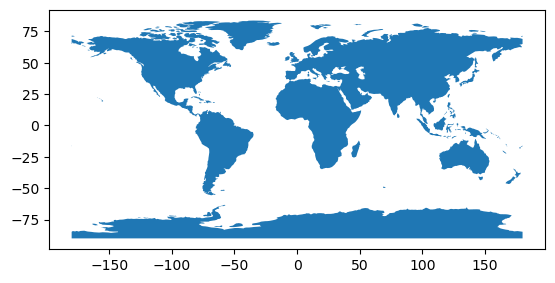

In [22]:
import geopandas
import matplotlib.pyplot as plt
from cartopy import crs as ccrs
from geodatasets import get_path

# let's get our basic earth data

path = get_path("naturalearth.land")
world = geopandas.read_file(path)

# and test our libraries loaded

world.plot()

In [24]:
# now convert latitude, longitude values into point geometry

gdf = geopandas.GeoDataFrame(
    df_area, geometry=geopandas.points_from_xy(df_area.longitude, df_area.latitude), crs="EPSG:4326"
)

# show top 3 records
gdf.head(3)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,geometry
0,-19.13594,128.25345,319.38,2.04,1.39,2026-04-17,35,Terra,MODIS,52,6.1NRT,303.31,25.61,D,POINT (128.25345 -19.13594)
1,-19.13279,128.25928,321.99,2.04,1.39,2026-04-17,35,Terra,MODIS,75,6.1NRT,302.81,34.80,D,POINT (128.25928 -19.13279)
2,-19.00206,124.81278,313.48,1.19,1.08,2026-04-17,35,Terra,MODIS,56,6.1NRT,303.26,7.18,D,POINT (124.81278 -19.00206)


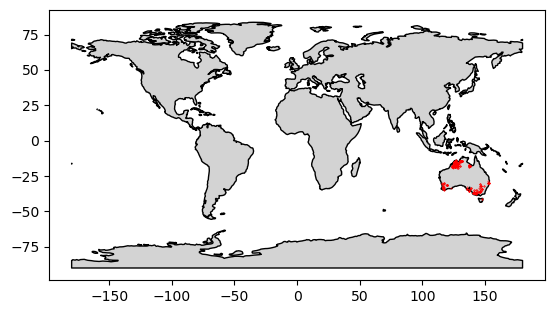

In [25]:
# optional: set outline and fill colors
ax = world.plot(color="lightgrey", edgecolor="black")

# We can now plot our ``GeoDataFrame``.
gdf.plot(ax=ax, color="red", markersize=0.1)

plt.show()

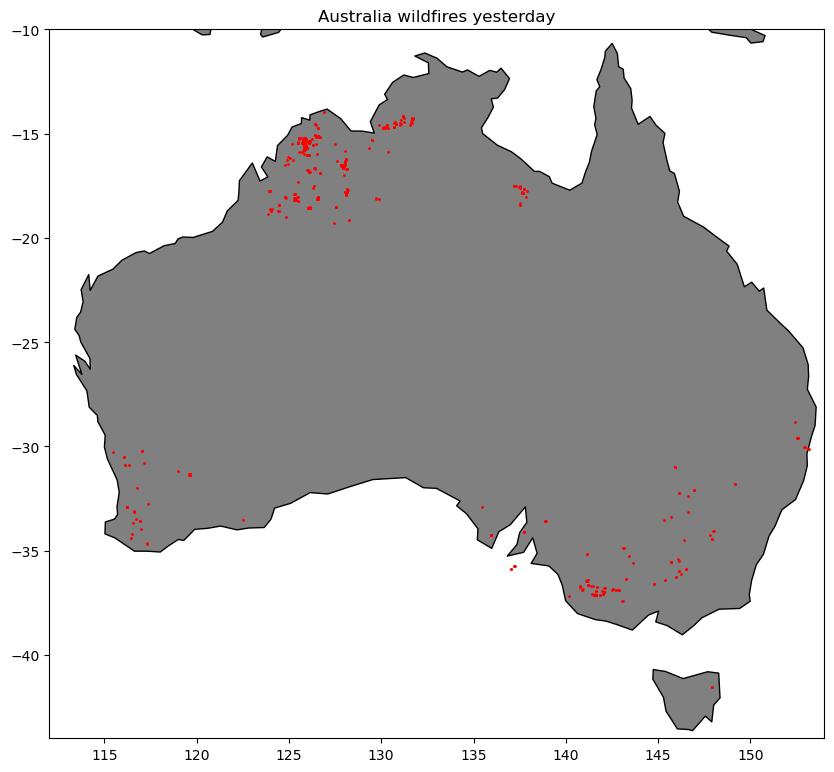

In [27]:
# create Australia subset

df_australia = df_area[(df_area['longitude'] >= 112) & (df_area['latitude'] >= -44) & (df_area['longitude'] <= 154) & (df_area['latitude'] <= -10)].copy()

# create geometry for points using latitude and longitude and specifying projection as EPSG:4326

gdf = geopandas.GeoDataFrame(
    df_australia, geometry=geopandas.points_from_xy(df_australia.longitude, df_australia.latitude), crs="EPSG:4326"
)

# set our extent
extent = [112, -44, 154, -10]
ax = world.plot(figsize=(10, 10), color="grey", edgecolor="black")
ax.set_xlim([extent[0],  extent[2]])
ax.set_ylim([extent[1],  extent[3]])

ax.set(title='Australia wildfires yesterday')

# We can now plot our ``GeoDataFrame``.
gdf.plot(ax=ax, color="red", markersize=1)

plt.show()

In [32]:
# convert aqc_date and aqc_time to acq_datetime as datetime object
df_australia['acq_datetime'] = pd.to_datetime(df_australia['acq_date'] + ' ' + df_australia['acq_time'].astype(str).str.zfill(4), format='%Y-%m-%d %H%M')
gdf = geopandas.GeoDataFrame(
    df_australia, geometry=geopandas.points_from_xy(df_australia.longitude, df_australia.latitude), crs="EPSG:4326"
)
# find maximum time from our dataset since we are pretending current date time is July 12 2023, 19:50(7:50pm) GMT.
# if the data were recent, we would set dt_max = pd.Timestamp.now();
dt_max = pd.Timestamp.now()

# create our subsets for 4 color classes

# less than or equal to 1 hour; gdf1 <= 1hour
gdf1 = gdf[gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=1))]

# greater than 1 hour but less than or equal to 4 hours; gdf2 > 1 hour and gdf2 <= 4 hours
gdf2 = gdf[(gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=4))) & (gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=1)))]

# greater than 4 hours but less than or equal to 12 hours; gdf3 > 4 hours and gdf2 <= 12 hours
gdf3 = gdf[(gdf['acq_datetime'] >= (dt_max - pd.Timedelta(hours=12))) & (gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=4)))]

# greater than 12 hours; gdf4 > 12 hours
gdf4 = gdf[gdf['acq_datetime'] < (dt_max - pd.Timedelta(hours=12))]

# now let's make sure the sizes are correct. They should all add up to 14045
print ('Sizes %i, %i, %i, %i from total of %i' % (gdf1.count()[0],gdf2.count()[0],gdf3.count()[0],gdf4.count()[0], gdf.count()[0]))

Sizes 0, 0, 387, 98 from total of 485


/var/folders/_9/03f8psw152b21w8xf61vy2900000gn/T/ipykernel_45588/3717916550.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print ('Sizes %i, %i, %i, %i from total of %i' % (gdf1.count()[0],gdf2.count()[0],gdf3.count()[0],gdf4.count()[0], gdf.count()[0]))
/var/folders/_9/03f8psw152b21w8xf61vy2900000gn/T/ipykernel_45588/3717916550.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print ('Sizes %i, %i, %i, %i from total of %i' % (gdf1.count()[0],gdf2.count()[0],gdf3.count()[0],gdf4.count()[0], gdf.count()[0]))
/var/folders/_9/03f8psw152b21w8xf61vy2900000gn/T/ipykernel_45588/3717916550.py:25: FutureWarning: Seri

ValueError: aspect must be finite and positive 

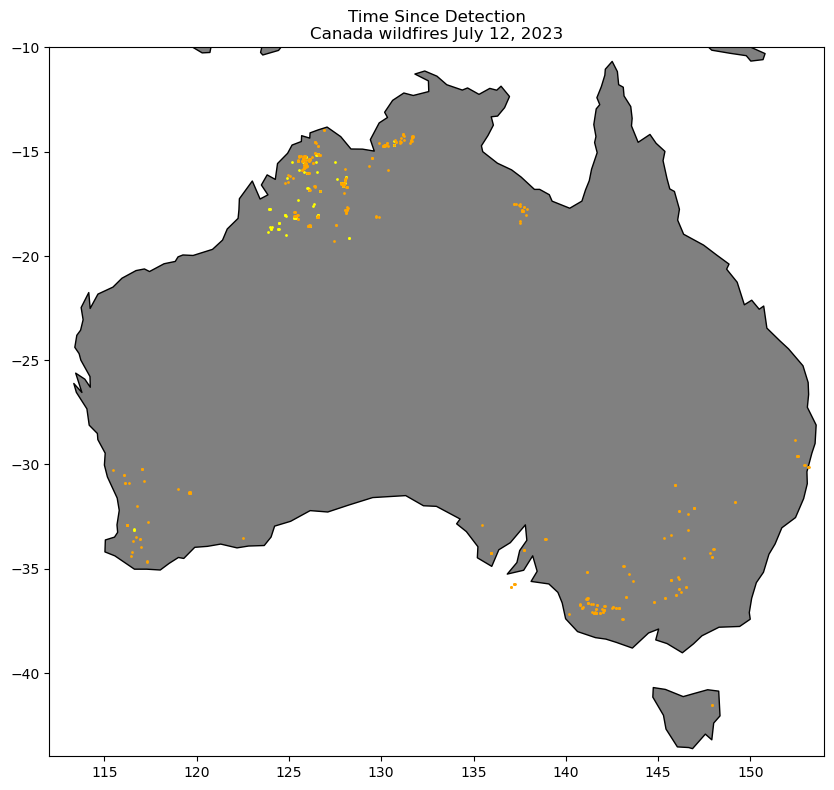

In [30]:
# set our extent to Australia
extent = [112, -44, 154, -10]
ax = world.plot(figsize=(10, 10), color="grey", edgecolor="black")

# set map extent
ax.set_xlim([extent[0],  extent[2]])
ax.set_ylim([extent[1],  extent[3]])

# add graph title
ax.set(title='Time Since Detection\nCanada wildfires July 12, 2023')

# Color code each set; also we are drawing in opposite order, so the older detections are drawn first so the newer ones are on the top
gdf4.plot(ax=ax, color="yellow", markersize=1)
gdf3.plot(ax=ax, color="orange", markersize=1)
gdf2.plot(ax=ax, color="red", markersize=1)
gdf1.plot(ax=ax, color="darkred", markersize=1)

plt.show()

/var/folders/_9/03f8psw152b21w8xf61vy2900000gn/T/ipykernel_45588/3559497508.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gdf4.count()[0] > 0 :
/var/folders/_9/03f8psw152b21w8xf61vy2900000gn/T/ipykernel_45588/3559497508.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gdf3.count()[0] > 0 :
/var/folders/_9/03f8psw152b21w8xf61vy2900000gn/T/ipykernel_45588/3559497508.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
 

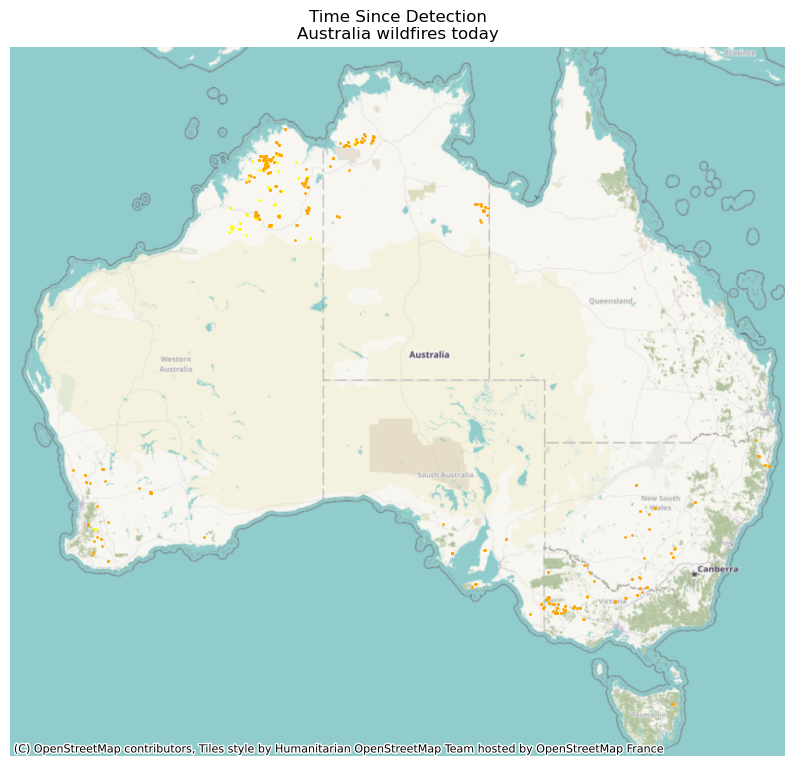

In [33]:
import contextily as cx

extent = [112, -44, 154, -10]
ax = world.plot(figsize=(10, 10), alpha=0)

# set our map extent
ax.set_xlim([extent[0],  extent[2]])
ax.set_ylim([extent[1],  extent[3]])

# set title
ax.set(title='Time Since Detection\nAustralia wildfires today')
# turn off axis labels
ax.set_axis_off()

# Color code each set; also we are drawing in opposite order, so the older detections are drawn first so the newer ones are on the top
if gdf4.count()[0] > 0 :
  gdf4.plot(ax=ax, color="yellow", markersize=1)
if gdf3.count()[0] > 0 :
  gdf3.plot(ax=ax, color="orange", markersize=1)
if gdf2.count()[0] > 0 :
  gdf2.plot(ax=ax, color="red", markersize=1)
if gdf1.count()[0] > 0 :
  gdf1.plot(ax=ax, color="darkred", markersize=1)

# add basemap
cx.add_basemap(ax, crs=gdf1.crs)

# show our map plot
plt.show()